# Analysis 3: Host Star Metallicity Dependence by Planet Size

**Author:** Aradhya Haldikar  
**Date:** March 2026  
**Corresponding paper:** *A Self‑Directed Census: Analyzing 6,105 Confirmed Exoplanets from First Principles*  
**GitHub repository:** [https://github.com/Dhpla12/exoplanet-analysis](https://github.com/Dhpla12/exoplanet-analysis)

---

## About this analysis

This notebook reproduces **Section 3.7** of the paper. It tests the well‑known planet–metallicity correlation by comparing stellar [Fe/H] distributions for different planet size classes.

### Goals:
- Fetch confirmed exoplanet data with stellar metallicity measurements.
- Apply a 30% radius uncertainty cut.
- Classify planets into three size bins: super‑Earths (<2 R⊕), sub‑Neptunes (2–4 R⊕), and giants (>4 R⊕).
- Plot normalized histograms of [Fe/H] for each class.
- Perform Kolmogorov–Smirnov tests to compare distributions.

### Data source:
- **Original data:** NASA Exoplanet Archive Planetary Systems Table (`ps`), DOI: [10.26133/NEA13](https://doi.org/10.26133/NEA13)
- **Filtered dataset:** Harvard Dataverse, DOI: [10.7910/DVN/WQGSNE](https://doi.org/10.7910/DVN/WQGSNE)

### Key result:
Giant planets orbit significantly more metal‑rich stars (mean [Fe/H] ≈ +0.09) than super‑Earths or sub‑Neptunes (mean ≈ solar). KS tests confirm the giant distribution differs at p ≪ 10⁻⁵⁰.

---

## How to use this notebook

1. Run all cells sequentially.
2. The histogram plot will appear, and KS test results will be printed.
3. Compare the statistics to the values reported in the paper.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 46.5 MB/s eta 0:00:00
Fetching confirmed planets data with stellar metallicity...
Total confirmed planets: 6128
Columns: ['pl_name', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'discoverymethod', 'st_met']

Planets with radius quality and metallicity: 2949

Counts by size class:
size_class
Sub-Neptune (2–4 R⊕)    1028
Super-Earth (<2 R⊕)      968
Giant (>4 R⊕)            953
Name: count, dtype: int64


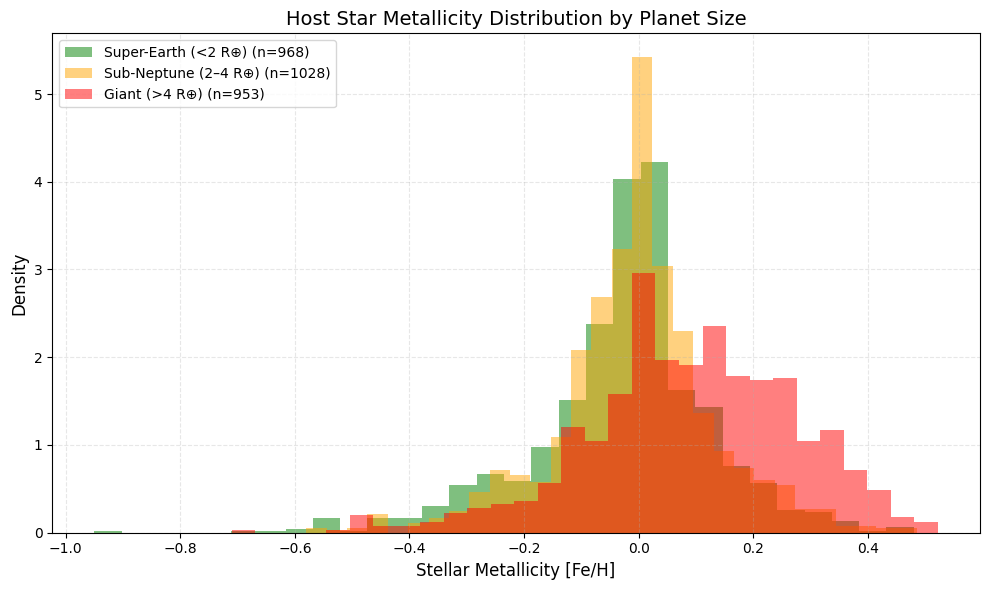


METALLICITY STATISTICS BY PLANET SIZE

Super-Earth (<2 R⊕) (n=968):
  Mean [Fe/H] = -0.027
  Median [Fe/H] = -0.010
  Std dev = 0.160

Sub-Neptune (2–4 R⊕) (n=1028):
  Mean [Fe/H] = -0.007
  Median [Fe/H] = 0.000
  Std dev = 0.142

Giant (>4 R⊕) (n=953):
  Mean [Fe/H] = 0.089
  Median [Fe/H] = 0.100
  Std dev = 0.184

KOLMOGOROV-SMIRNOV TESTS

Super-Earth (<2 R⊕) vs Sub-Neptune (2–4 R⊕):
  KS statistic = 0.057
  p-value = 7.456e-02
  → No significant difference (p >= 0.05)

Super-Earth (<2 R⊕) vs Giant (>4 R⊕):
  KS statistic = 0.358
  p-value = 2.291e-55
  → Distributions are significantly different (p < 0.05)

Sub-Neptune (2–4 R⊕) vs Giant (>4 R⊕):
  KS statistic = 0.337
  p-value = 3.356e-50
  → Distributions are significantly different (p < 0.05)


In [1]:
# =============================================================================
# Analysis 3: Host Star Metallicity Dependence by Planet Size
# =============================================================================

# Install astroquery
!pip install astroquery --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

# 1. Fetch data with metallicity
print("Fetching confirmed planets data with stellar metallicity...")
df3 = NasaExoplanetArchive.query_criteria(
    table="ps",
    select="pl_name, pl_rade, pl_radeerr1, pl_radeerr2, discoverymethod, st_met",
    where="default_flag=1",
    cache=False
).to_pandas()

print(f"Total confirmed planets: {len(df3)}")
print(f"Columns: {df3.columns.tolist()}\n")

# 2. Apply radius quality cut
rade_ok = df3['pl_rade'].notna() & df3['pl_radeerr1'].notna() & df3['pl_radeerr2'].notna()
df3['rade_frac_err'] = np.nan
df3.loc[rade_ok, 'rade_frac_err'] = np.maximum(df3.loc[rade_ok, 'pl_radeerr1'], df3.loc[rade_ok, 'pl_radeerr2']) / df3.loc[rade_ok, 'pl_rade']
df3['rade_quality'] = df3['rade_frac_err'] < 0.3

# Also need metallicity
has_met = df3['st_met'].notna()
good_for_met = df3['rade_quality'] & has_met
df_met = df3[good_for_met].copy()

print(f"Planets with radius quality and metallicity: {len(df_met)}")

# 3. Classify by size (following common definitions)
def size_class(radius):
    if radius < 2:
        return 'Super-Earth (<2 R⊕)'
    elif radius < 4:
        return 'Sub-Neptune (2–4 R⊕)'
    else:
        return 'Giant (>4 R⊕)'

df_met['size_class'] = df_met['pl_rade'].apply(size_class)

print("\nCounts by size class:")
print(df_met['size_class'].value_counts())

# 4. Plot metallicity distributions
plt.figure(figsize=(10, 6))
classes = ['Super-Earth (<2 R⊕)', 'Sub-Neptune (2–4 R⊕)', 'Giant (>4 R⊕)']
colors = ['green', 'orange', 'red']

for i, (size, color) in enumerate(zip(classes, colors)):
    subset = df_met[df_met['size_class'] == size]
    plt.hist(subset['st_met'].dropna(), bins=30, alpha=0.5,
             color=color, label=f"{size} (n={len(subset)})", density=True)

plt.xlabel('Stellar Metallicity [Fe/H]', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Host Star Metallicity Distribution by Planet Size', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Print statistics
print("\n" + "="*60)
print("METALLICITY STATISTICS BY PLANET SIZE")
print("="*60)
for size in classes:
    subset = df_met[df_met['size_class'] == size]
    met_vals = subset['st_met'].dropna()
    if len(met_vals) > 0:
        print(f"\n{size} (n={len(met_vals)}):")
        print(f"  Mean [Fe/H] = {met_vals.mean():.3f}")
        print(f"  Median [Fe/H] = {met_vals.median():.3f}")
        print(f"  Std dev = {met_vals.std():.3f}")

# 6. Optional: KS test to compare distributions
from scipy.stats import ks_2samp

print("\n" + "="*60)
print("KOLMOGOROV-SMIRNOV TESTS")
print("="*60)
for i, size1 in enumerate(classes):
    for size2 in classes[i+1:]:
        data1 = df_met[df_met['size_class'] == size1]['st_met'].dropna()
        data2 = df_met[df_met['size_class'] == size2]['st_met'].dropna()
        if len(data1) > 0 and len(data2) > 0:
            stat, p = ks_2samp(data1, data2)
            print(f"\n{size1} vs {size2}:")
            print(f"  KS statistic = {stat:.3f}")
            print(f"  p-value = {p:.3e}")
            if p < 0.05:
                print(f"  → Distributions are significantly different (p < 0.05)")
            else:
                print(f"  → No significant difference (p >= 0.05)")